In [2]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_csv('voice.csv')

# Check dataset
print(df.head())
print(df.shape)
print(df.columns)

   meanfreq        sd    median       Q25       Q75       IQR       skew  \
0  0.059781  0.064241  0.032027  0.015071  0.090193  0.075122  12.863462   
1  0.066009  0.067310  0.040229  0.019414  0.092666  0.073252  22.423285   
2  0.077316  0.083829  0.036718  0.008701  0.131908  0.123207  30.757155   
3  0.151228  0.072111  0.158011  0.096582  0.207955  0.111374   1.232831   
4  0.135120  0.079146  0.124656  0.078720  0.206045  0.127325   1.101174   

          kurt    sp.ent       sfm  ...  centroid   meanfun    minfun  \
0   274.402906  0.893369  0.491918  ...  0.059781  0.084279  0.015702   
1   634.613855  0.892193  0.513724  ...  0.066009  0.107937  0.015826   
2  1024.927705  0.846389  0.478905  ...  0.077316  0.098706  0.015656   
3     4.177296  0.963322  0.727232  ...  0.151228  0.088965  0.017798   
4     4.333713  0.971955  0.783568  ...  0.135120  0.106398  0.016931   

     maxfun   meandom    mindom    maxdom   dfrange   modindx  label  
0  0.275862  0.007812  0.007812  

In [3]:
X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=1))
])

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9810725552050473
              precision    recall  f1-score   support

      female       0.98      0.98      0.98       317
        male       0.98      0.98      0.98       317

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634



In [4]:
from sklearn.feature_selection import f_classif

F, p = f_classif(X, y)

feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': F,
    'p-value': p
})

feature_scores = feature_scores.sort_values(
    'F-Score',
    ascending=False
)

print(feature_scores)

     Feature      F-Score        p-value
12   meanfun  7228.790362   0.000000e+00
5        IQR  1965.750000   0.000000e+00
3        Q25  1121.569224  9.140832e-211
8     sp.ent  1003.308717  1.614016e-191
1         sd   945.461376  6.654756e-182
9        sfm   463.923194   3.877715e-96
11  centroid   406.752820   3.368951e-85
0   meanfreq   406.752820   3.368951e-85
2     median   277.588158   8.259210e-60
17    maxdom   126.024161   1.050986e-28
16    mindom   125.110999   1.636130e-28
18   dfrange   121.457858   9.626061e-28
15   meandom   119.959108   1.992966e-27
10      mode    96.257909   2.097044e-22
14    maxfun    90.228036   4.044625e-21
13    minfun    60.282137   1.101400e-14
7       kurt    24.255365   8.869557e-07
4        Q75    14.236082   1.642021e-04
6       skew     4.252980   3.926293e-02
19   modindx     3.006445   8.303136e-02


In [5]:
from sklearn.feature_selection import f_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# Urutkan fitur berdasarkan F-Score
ranked_features = feature_scores['Feature'].tolist()

results = []

# Uji jumlah fitur dari 1 sampai 20
for n_features in range(1, len(ranked_features) + 1):

    selected_features = ranked_features[:n_features]

    X_selected = df[selected_features]

    X_train, X_test, y_train, y_test = train_test_split(
        X_selected,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # Uji K = 1 sampai 20
    for k in range(1, 21):

        model = Pipeline([
            ('scaler', StandardScaler()),
            ('knn', KNeighborsClassifier(n_neighbors=k))
        ])

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)

        results.append({
            'Number of Features': n_features,
            'K': k,
            'Accuracy': accuracy
        })

results_df = pd.DataFrame(results)

# Cari kombinasi terbaik
best_result = results_df.loc[
    results_df['Accuracy'].idxmax()
]

print("Best Result:")
print(best_result)

Best Result:
Number of Features    9.000000
K                     6.000000
Accuracy              0.988959
Name: 165, dtype: float64


In [6]:
best_n = int(best_result['Number of Features'])
best_k = int(best_result['K'])

best_features = ranked_features[:best_n]

print("Best Number of Features:", best_n)
print("Best K:", best_k)
print("Best Accuracy:", best_result['Accuracy'])

print("\nSelected Features:")
for feature in best_features:
    print("-", feature)

Best Number of Features: 9
Best K: 6
Best Accuracy: 0.9889589905362776

Selected Features:
- meanfun
- IQR
- Q25
- sp.ent
- sd
- sfm
- centroid
- meanfreq
- median


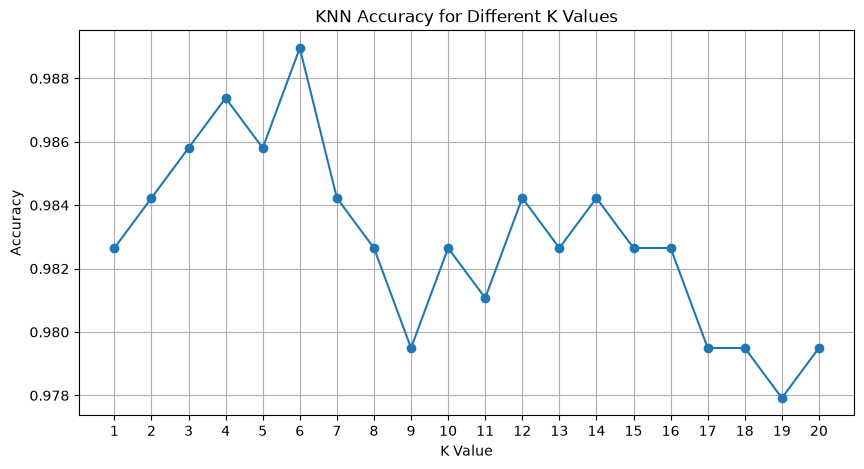

In [7]:
import matplotlib.pyplot as plt

# Ambil hasil untuk 9 fitur terbaik
plot_data = results_df[
    results_df['Number of Features'] == best_n
]

plt.figure(figsize=(10, 5))

plt.plot(
    plot_data['K'],
    plot_data['Accuracy'],
    marker='o'
)

plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy for Different K Values')
plt.xticks(range(1, 21))
plt.grid()

plt.show()

# 1. Construct a KNN classification model to classify male and female voice types

A K-Nearest Neighbors (KNN) classification model was constructed to classify voice types into male and female classes using the `voice.csv` dataset.

The dataset was divided into 80% training data and 20% testing data using `train_test_split` with `random_state = 42` and stratification based on the target class. Since the voice features have different scales, StandardScaler was applied before the KNN classification process.

Feature selection was performed using the ANOVA F-score to determine which features had the strongest relationship with the target class. The features were then ranked based on their F-score and tested using different numbers of features and K values.

The best model obtained an accuracy of approximately 98.90%.

---

# 2. Experiment with features to find the optimal features

Based on the ANOVA F-score analysis, the nine features that produced the best KNN performance were:

| No. | Feature |
|---|---|
| 1 | `meanfun` |
| 2 | `IQR` |
| 3 | `Q25` |
| 4 | `sp.ent` |
| 5 | `sd` |
| 6 | `sfm` |
| 7 | `centroid` |
| 8 | `meanfreq` |
| 9 | `median` |

These features were selected because they had relatively high F-scores and provided the best classification performance when combined in the KNN model.

Using these nine features, the model achieved an accuracy of approximately:

98.90%

This result shows that the model can classify male and female voices with very high accuracy while reducing the number of features from the original 20 features to 9 features.

---

# 3. Determine the best K and provide analysis

The value of K was tested from 1 to 20 using the nine selected features. The accuracy for each K value was calculated and visualized using a KNN accuracy graph.

The best result was obtained with:

-Number of features: 9
- est K:6
- Accuracy: 0.988959
- Accuracy percentage: 98.90%

The value K = 6 was selected because it produced the highest classification accuracy among the tested K values for the selected feature set.

A very small K value can make KNN sensitive to individual data points and noise, while a very large K value can make the model too generalized. Therefore, K = 6 provides the best result for this dataset based on the experimental evaluation.

# Conclusion

The KNN model successfully classified male and female voice types with an accuracy of approximately 98.90%. The optimal configuration used 9 selected features and K = 6. Feature selection reduced the dimensionality of the dataset while maintaining a very high classification performance.